[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/liviaellen/llm-persona-review/blob/main/analysis/persona_review_statistical_analysis.ipynb)

# Statistical analysis of the LLM persona literature review

This notebook analyzes the 70-paper coded corpus accompanying *The Effects of Personas on LLM Generative Output and LLM-as-a-Judge Evaluation: A Literature Review*. It asks: **How is the literature distributed over time and study design, and is the coded direction of persona effects associated with publication year or analysis theme?**

> **Interpretation boundary:** each row is a paper, not an independent experiment or participant. The sample is a reviewed corpus rather than a random sample, and the effect label is a review-level code. Results are therefore descriptive and associational—not causal estimates of whether personas work.

In [1]:
from pathlib import Path
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportion_confint

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", 80)
RANDOM_SEED = 42

## Load and validate the data

The loader first looks for the CSV in a local clone. In Colab, where that relative path is absent, it downloads the same file from GitHub. Header whitespace and trailing asterisks are normalized because the source export contains both.

In [2]:
DATA_PATH = Path("../data/persona_llm_review.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("data/persona_llm_review.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("persona_llm_review.csv")
    urlretrieve(
        "https://raw.githubusercontent.com/liviaellen/llm-persona-review/main/data/persona_llm_review.csv",
        DATA_PATH,
    )

df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip().str.rstrip("*")
for column in ["Type", "Analysis Theme", "Effect of Personas on LLM Output", "Review Research Question"]:
    df[column] = df[column].str.strip()
df["Human participation"] = np.where(df["Human Participants?"].str.strip().str.upper().str.startswith("Y"), "Yes", "No")
df["Persona sample size"] = pd.to_numeric(df["Sample Size of Personas/Profiles"].str.replace(",", "", regex=False), errors="coerce")

expected = {"article_id", "Year", "Analysis Theme", "Effect of Personas on LLM Output"}
assert expected.issubset(df.columns), f"Missing columns: {expected - set(df.columns)}"
assert df["article_id"].is_unique, "article_id should uniquely identify papers"
assert df["Year"].between(2023, 2026).all(), "Unexpected publication year"
assert set(df["Effect of Personas on LLM Output"]) <= {"Positive", "Negative", "Mixed"}

print(f"Loaded {len(df)} papers and {df.shape[1]} fields from {DATA_PATH}.")
pd.DataFrame({"dtype": df.dtypes.astype(str), "missing_n": df.isna().sum(), "missing_pct": df.isna().mean().mul(100).round(1)})

Loaded 70 papers and 20 fields from ../data/persona_llm_review.csv.


,dtype,missing_n,missing_pct
article_id,object,0,0.0
Year,int64,0,0.0
Type,object,0,0.0
Keywords,object,0,0.0
Title,object,0,0.0
Authors,object,0,0.0
First Author,object,0,0.0
Retrieved,object,0,0.0
Analysis Theme,object,0,0.0
LLMs Used,object,4,5.7


## Corpus composition

Counts and percentages are the clearest summaries for the coded categorical fields. Wilson 95% confidence intervals are included for effect-category proportions; they quantify count uncertainty but should not be read as population-sampling intervals because this is a literature-review corpus.

In [3]:
def frequency_table(series):
    counts = series.value_counts()
    return pd.DataFrame({"n": counts, "percent": (100 * counts / counts.sum()).round(1)})

display(frequency_table(df["Year"]).sort_index())
display(frequency_table(df["Analysis Theme"]))

effect_counts = df["Effect of Personas on LLM Output"].value_counts().reindex(["Positive", "Mixed", "Negative"])
ci_low, ci_high = proportion_confint(effect_counts, len(df), alpha=0.05, method="wilson")
effect_summary = pd.DataFrame({
    "n": effect_counts,
    "percent": (100 * effect_counts / len(df)).round(1),
    "95% CI low": (100 * ci_low).round(1),
    "95% CI high": (100 * ci_high).round(1),
})
display(effect_summary)

,n,percent
Year,,
2023,2,2.9
2024,23,32.9
2025,35,50.0
2026,10,14.3


,n,percent
Analysis Theme,,
quantitative,49,70.0
mixed,18,25.7
qualitative,3,4.3


,n,percent,95% CI low,95% CI high
Effect of Personas on LLM Output,,,,
Positive,27,38.6,28.0,50.3
Mixed,21,30.0,20.5,41.5
Negative,22,31.4,21.8,43.0


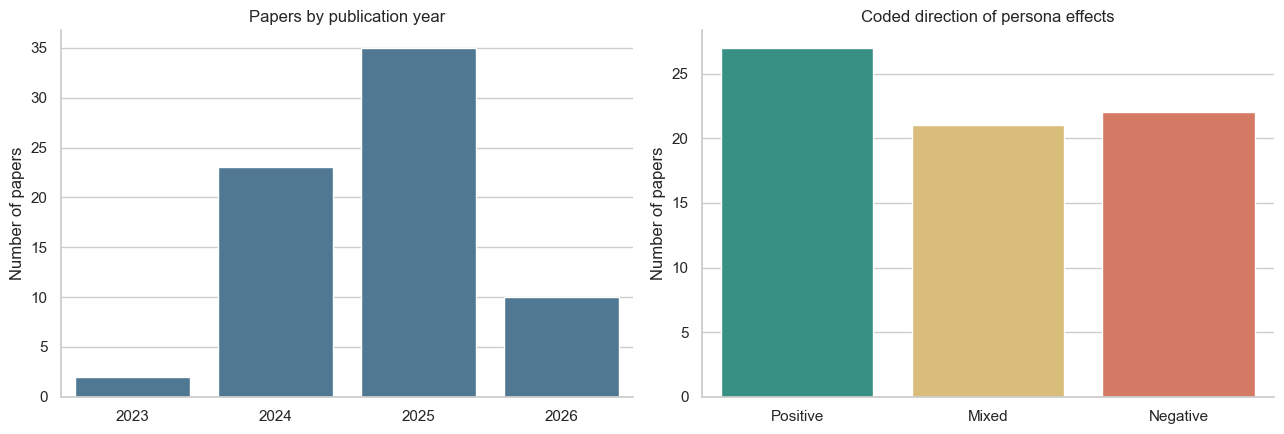

In [4]:
effect_order = ["Positive", "Mixed", "Negative"]
palette = {"Positive": "#2a9d8f", "Mixed": "#e9c46a", "Negative": "#e76f51"}

FIGURE_DIR = Path("analysis/figures") if Path("analysis").exists() else Path("figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.countplot(data=df, x="Year", color="#457b9d", ax=axes[0])
axes[0].set(title="Papers by publication year", ylabel="Number of papers", xlabel="")
sns.countplot(data=df, x="Effect of Personas on LLM Output", order=effect_order, palette=palette, hue="Effect of Personas on LLM Output", legend=False, ax=axes[1])
axes[1].set(title="Coded direction of persona effects", ylabel="Number of papers", xlabel="")
sns.despine(fig=fig)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "corpus_overview.png", dpi=200, bbox_inches="tight")
plt.show()

## Association between study characteristics and coded effect

Pearson's chi-square test assesses whether the distribution of Positive/Mixed/Negative labels differs across groups. Cramér's V reports association strength on a 0–1 scale. Because sparse expected cells weaken the usual chi-square approximation, the function also reports the minimum expected count and the percentage below 5. Treat tests with sparse tables as exploratory. No multiple-testing correction is applied because only two pre-specified associations are examined.

In [5]:
def chi_square_report(group_col):
    table = pd.crosstab(df[group_col], df["Effect of Personas on LLM Output"]).reindex(columns=effect_order, fill_value=0)
    chi2, p_value, dof, expected = chi2_contingency(table)
    n = table.to_numpy().sum()
    cramers_v = np.sqrt(chi2 / (n * min(table.shape[0] - 1, table.shape[1] - 1)))
    diagnostics = pd.Series({
        "chi-square": chi2, "degrees of freedom": dof, "p-value": p_value,
        "Cramer's V": cramers_v, "minimum expected count": expected.min(),
        "expected cells below 5 (%)": 100 * (expected < 5).mean(),
    }).round(4)
    return table, diagnostics

for grouping in ["Analysis Theme", "Year"]:
    observed, statistics = chi_square_report(grouping)
    print(f"\nEffect category by {grouping}")
    display(observed)
    display(statistics.to_frame("value"))


Effect category by Analysis Theme


Effect of Personas on LLM Output,Positive,Mixed,Negative
Analysis Theme,,,
mixed,10,5,3
qualitative,1,2,0
quantitative,16,14,19


,value
chi-square,6.2523
degrees of freedom,4.0000
p-value,0.1811
Cramer's V,0.2113
minimum expected count,0.9000
expected cells below 5 (%),33.3333



Effect category by Year


Effect of Personas on LLM Output,Positive,Mixed,Negative
Year,,,
2023,0,1,1
2024,7,7,9
2025,15,11,9
2026,5,2,3


,value
chi-square,3.3205
degrees of freedom,6.0000
p-value,0.7677
Cramer's V,0.1540
minimum expected count,0.6000
expected cells below 5 (%),50.0000


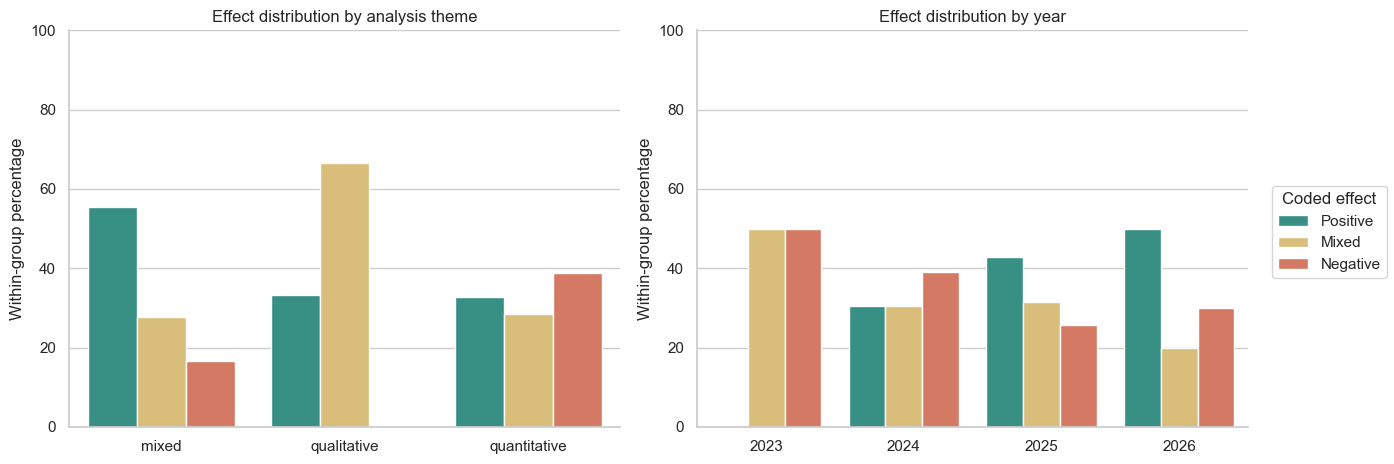

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for ax, grouping in zip(axes, ["Analysis Theme", "Year"]):
    shares = (pd.crosstab(df[grouping], df["Effect of Personas on LLM Output"], normalize="index")
              .reindex(columns=effect_order, fill_value=0).mul(100).rename_axis(index=grouping).reset_index()
              .melt(id_vars=grouping, var_name="Effect", value_name="Percent"))
    sns.barplot(data=shares, x=grouping, y="Percent", hue="Effect", hue_order=effect_order, palette=palette, ax=ax)
    ax.set(title=f"Effect distribution by {grouping.lower()}", xlabel="", ylabel="Within-group percentage", ylim=(0, 100))
    ax.legend_.remove()
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, title="Coded effect", loc="center right")
sns.despine(fig=fig)
fig.tight_layout(rect=(0, 0, 0.91, 1))
fig.savefig(FIGURE_DIR / "effect_by_design_and_year.png", dpi=200, bbox_inches="tight")
plt.show()

## Checks against the manuscript

The following tables reproduce the quantities reported in Tables 2 and 3 of `HICSS_Paper.pdf` from the current CSV. Highlighted differences indicate manuscript values that should be checked or updated. The sample-size chart uses a log scale because values range from 2 to 1,000,000.

In [7]:
sample_current = (df.groupby("Effect of Personas on LLM Output")["Persona sample size"]
                  .agg(N="count", Min="min", Median="median", Mean="mean", Max="max")
                  .reindex(effect_order).round(1))
sample_reported = pd.DataFrame({
    "N": [16, 15, 19], "Min": [2, 4, 4], "Median": [31, 100, 1000],
    "Mean": [866, 11743, 62789], "Max": [6948, 165480, 1000000],
}, index=effect_order)
display(pd.concat({"Current CSV": sample_current, "Reported Table 2": sample_reported}, axis=1))
display((sample_current - sample_reported).rename_axis("Effect").style.applymap(lambda x: "background-color: #ffd6d6" if x != 0 else ""))

Current CSV                                  Reported Table 2      \
                   N  Min  Median     Mean        Max                N Min   
Positive          16  2.0    41.0   2739.1    30000.0               16   2   
Mixed             15  4.0   100.0  11743.0   165480.0               15   4   
Negative          19  4.0  1000.0  62789.0  1000000.0               19   4   

                                 
         Median   Mean      Max  
Positive     31    866     6948  
Mixed       100  11743   165480  
Negative   1000  62789  1000000

/var/folders/0h/b8g8b1rd72x_2hsdhsv135_h0000gn/T/ipykernel_57554/2841454901.py:9: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  display((sample_current - sample_reported).rename_axis("Effect").style.applymap(lambda x: "background-color: #ffd6d6" if x != 0 else ""))


,N,Min,Median,Mean,Max
Effect,,,,,
Positive,0,0.000000,10.000000,1873.100000,23052.000000
Mixed,0,0.000000,0.000000,0.000000,0.000000
Negative,0,0.000000,0.000000,0.000000,0.000000


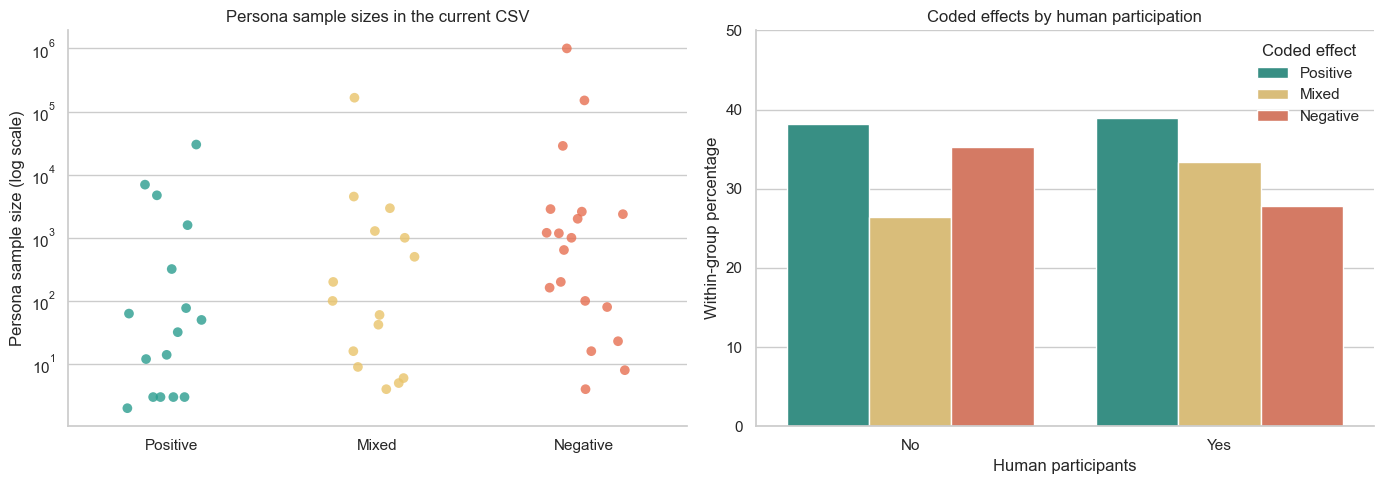

Effect of Personas on LLM Output,Positive,Mixed,Negative,All
Human participation,,,,
No,13,9,12,34
Yes,14,12,10,36
All,27,21,22,70


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.stripplot(data=df, x="Effect of Personas on LLM Output", y="Persona sample size", order=effect_order, hue="Effect of Personas on LLM Output", palette=palette, legend=False, jitter=0.22, size=7, alpha=0.8, ax=axes[0])
axes[0].set_yscale("log")
axes[0].set(title="Persona sample sizes in the current CSV", xlabel="", ylabel="Persona sample size (log scale)")
human_shares = (pd.crosstab(df["Human participation"], df["Effect of Personas on LLM Output"], normalize="index")
                .reindex(columns=effect_order).mul(100).reset_index().melt(id_vars="Human participation", var_name="Effect", value_name="Percent"))
sns.barplot(data=human_shares, x="Human participation", y="Percent", hue="Effect", hue_order=effect_order, palette=palette, ax=axes[1])
axes[1].set(title="Coded effects by human participation", xlabel="Human participants", ylabel="Within-group percentage", ylim=(0, 50))
axes[1].legend(title="Coded effect", frameon=False)
sns.despine(fig=fig)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "sample_size_and_human_participation.png", dpi=200, bbox_inches="tight")
plt.show()
display(pd.crosstab(df["Human participation"], df["Effect of Personas on LLM Output"], margins=True).reindex(columns=effect_order + ["All"]))

### Discrepancies found

1. **Human-participant total:** the current CSV and manuscript Table 1 give **36 Yes + 34 No = 70**. The Results prose and Table 3 instead give **37 Yes + 34 No = 71**. With the current CSV, the Yes effect counts are Positive 14, Mixed 12, Negative 10; Table 3 reports Mixed 13.
2. **RQ percentages:** the counts 37, 14, and 19 are correct, but their percentages out of 70 are **52.9%, 20.0%, and 27.1%**, not 52.1%, 19.7%, and 26.8%.
3. **Positive sample-size summary:** the current CSV has 16 numeric positive-effect sample sizes with Min 2, Median 41, Mean 2,739.1, Max 30,000. Table 2 reports 16, 2, 31, 866, and 6,948. The current value `A21 = 30,000` is the largest source of the difference, but removing it still does not fully reproduce the reported row; reconcile Table 2 with the intended data version.
4. **Human-participation percentage wording:** after correction, Positive is 14/36 = **38.9%** for Yes and 13/34 = **38.2%** for No.
5. **Rounding:** the conclusion's 39% Positive, 31% Negative, and 30% Mixed is consistent with 27/70, 22/70, and 21/70 after rounding.

## Reproducible interpretation

This final cell writes a short interpretation directly from the computed values, keeping the narrative synchronized with the data. Statistical significance is not evidence of causality, while non-significance is not proof that groups are identical—especially with small or sparse cells.

In [9]:
largest_year = df["Year"].value_counts().idxmax()
largest_year_n = df["Year"].value_counts().max()
top_effect = effect_counts.idxmax()
top_effect_n = effect_counts.max()

print(f"The corpus is concentrated in {largest_year} ({largest_year_n}/{len(df)} papers).")
print(f"{top_effect} is the most frequent effect code ({top_effect_n}/{len(df)}, {100*top_effect_n/len(df):.1f}%), but all three categories are common.")
for grouping in ["Analysis Theme", "Year"]:
    _, stats = chi_square_report(grouping)
    evidence = "shows evidence of an association" if stats["p-value"] < 0.05 else "does not show clear evidence of an association"
    sparse = " The expected-count diagnostic is sparse, so interpret this result cautiously." if stats["expected cells below 5 (%)"] > 20 else ""
    v = stats["Cramer's V"]
    print(f"The exploratory chi-square test for {grouping} {evidence} (p={stats['p-value']:.3f}, Cramer's V={v:.2f}).{sparse}")

The corpus is concentrated in 2025 (35/70 papers).
Positive is the most frequent effect code (27/70, 38.6%), but all three categories are common.
The exploratory chi-square test for Analysis Theme does not show clear evidence of an association (p=0.181, Cramer's V=0.21). The expected-count diagnostic is sparse, so interpret this result cautiously.
The exploratory chi-square test for Year does not show clear evidence of an association (p=0.768, Cramer's V=0.15). The expected-count diagnostic is sparse, so interpret this result cautiously.


## Limitations and next steps

- Paper-level labels compress heterogeneous tasks, models, persona definitions, and outcome measures.
- Papers may report multiple experiments, so equal paper weighting is a pragmatic review summary rather than an effect-size meta-analysis.
- Publication year and design groups contain small cells; asymptotic p-values can be unstable.
- The corpus ends in 2026 and should be treated as a snapshot of the review search and inclusion process.
- A formal meta-analysis would require comparable quantitative effect sizes, their standard errors, and explicit handling of dependent effects within papers.